# Теория вероятности

*Большая часть базы для этой темы описана в дискретной вероятности. Основное отличие от дискретной в том, что тут непрерывная величина (температура, время ожидания, рост)*

Вероятность в точке равна нулю (это связано с тем, что непрерывной величине учитываются вообще все вероятности, в том числе например для X = 17.000000000000001. Из-за чего выходит, что чтобы сумма всех вероятностей дала 1, все остальные величины должны иметь очень маленькую вероятность стремящуюся к нулю)
$$
P(X = x) = 0
$$

## Плотность вероятности и вероятность в интервале

**Плотность вероятности(PDF)** - это сложно понятие, но это буквально производная, только для вероятности. То есть мы так же можем её расматривать как некую скорость
$$
f(x)
$$

**Вероятность в интервале** - продолжая аналогию, находя площадь под кривой находим путь, в нашем случаи путь это вероятность (при этом мы не забываем, что сумма всех вероятностей даёт 1, это правило остаётся):
$$
P(a \le X \le b) = \int_{a}^{b} f(x) dx
$$
$$
\int_{- \infty}^{\infty} f(x) dx = 1
$$

## Функция распределения (CDF)

Мы уже проходили это в дискретном случаи. Это накопленная вероятность до точки $x$. Напоминаю, что в дискретном случаи она выглядела так, где $x$ - это именно значение:
$$
F(x) = P(X \le x)
$$

Формула для непрерывной вероятности:
$$
F(x) = \int_{-\infty}^{x} f(t) dt
$$

*Здесь может смутить непонятная $t$, но по сути эта $t$ - это тоже $x$. Они находятся на одной оси: $x$ - обозначает конкретную точку, $t$ - проходится от минус бесконечности до $x$*

Можно прям тут найти вероятность интервала (a,b):
$$
P(a \le X \le b) = F(b) - F(a)
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

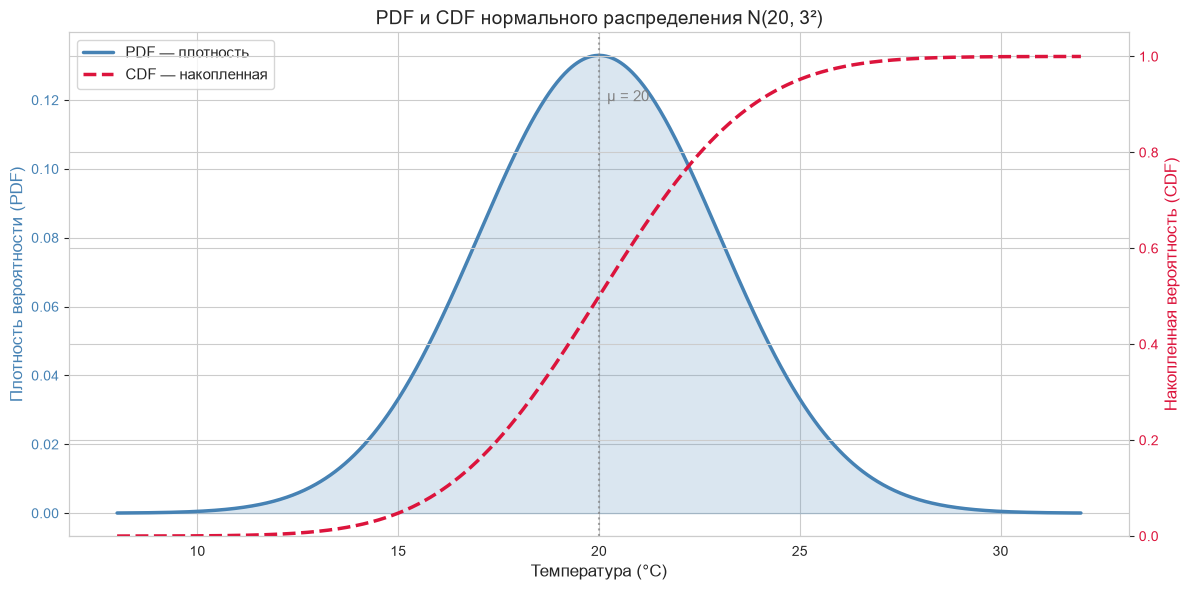

In [2]:
# Параметры нормального распределения
mu = 20      # средняя температура
sigma = 3    # стандартное отклонение

# Диапазон значений
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF и CDF
pdf = stats.norm.pdf(x, mu, sigma)
cdf = stats.norm.cdf(x, mu, sigma)

# График
fig, ax1 = plt.subplots(figsize=(12, 6))

# PDF — на левой оси Y
color_pdf = 'steelblue'
ax1.set_xlabel('Температура (°C)', fontsize=12)
ax1.set_ylabel('Плотность вероятности (PDF)', color=color_pdf, fontsize=12)
ax1.plot(x, pdf, color=color_pdf, linewidth=2.5, label='PDF — плотность')
ax1.tick_params(axis='y', labelcolor=color_pdf)
ax1.fill_between(x, pdf, alpha=0.2, color=color_pdf)

# CDF — на правой оси Y
ax2 = ax1.twinx()
color_cdf = 'crimson'
ax2.set_ylabel('Накопленная вероятность (CDF)', color=color_cdf, fontsize=12)
ax2.plot(x, cdf, color=color_cdf, linewidth=2.5, linestyle='--', label='CDF — накопленная')
ax2.tick_params(axis='y', labelcolor=color_cdf)
ax2.set_ylim(0, 1.05)

# Вертикальная линия на среднем
ax1.axvline(mu, color='gray', linestyle=':', alpha=0.7)
ax1.text(mu, max(pdf)*0.9, f'  μ = {mu}', fontsize=11, color='gray')

# Заголовок
plt.title(f'PDF и CDF нормального распределения N({mu}, {sigma}²)', fontsize=14)

# Легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

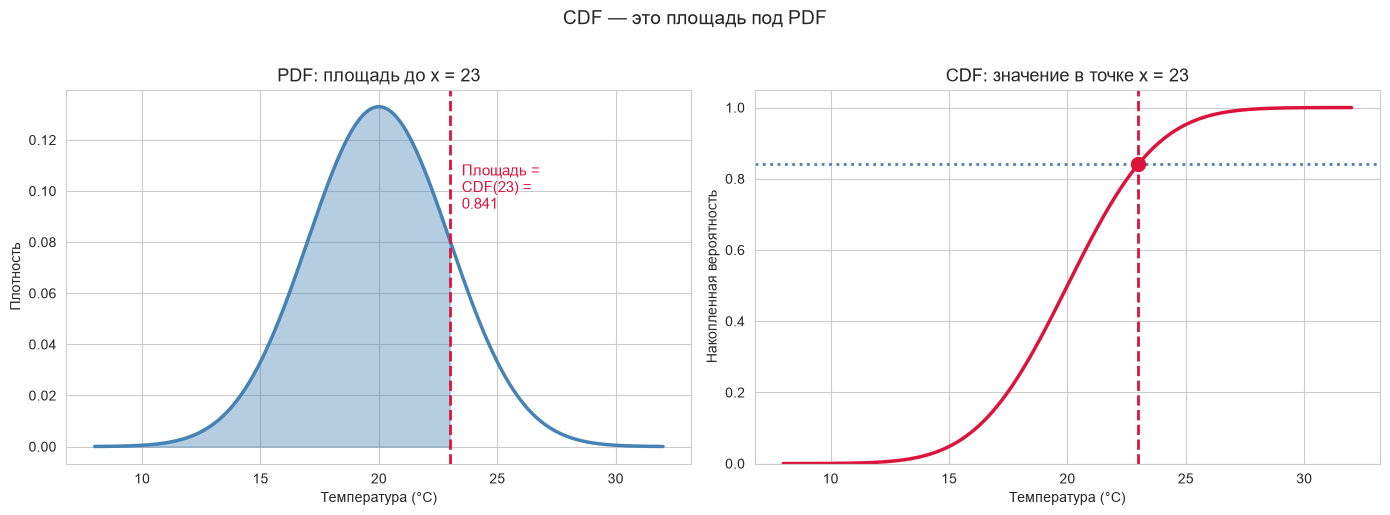

In [3]:
# Демонстрация: CDF(x) = площадь под PDF до x
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Возьмём точку для примера
x_point = 23

# Левый график: PDF с закрашенной площадью до x_point
axes[0].plot(x, pdf, color='steelblue', linewidth=2.5)
axes[0].fill_between(x[x <= x_point], pdf[x <= x_point],
                     alpha=0.4, color='steelblue')
axes[0].axvline(x_point, color='crimson', linestyle='--', linewidth=2)
axes[0].set_title(f'PDF: площадь до x = {x_point}', fontsize=13)
axes[0].set_xlabel('Температура (°C)')
axes[0].set_ylabel('Плотность')
axes[0].text(x_point + 0.5, max(pdf)*0.7,
             f'Площадь =\nCDF({x_point}) =\n{stats.norm.cdf(x_point, mu, sigma):.3f}',
             fontsize=11, color='crimson')

# Правый график: CDF с точкой
axes[1].plot(x, cdf, color='crimson', linewidth=2.5)
axes[1].axvline(x_point, color='crimson', linestyle='--', linewidth=2)
axes[1].axhline(stats.norm.cdf(x_point, mu, sigma),
                color='steelblue', linestyle=':', linewidth=2)
axes[1].scatter([x_point], [stats.norm.cdf(x_point, mu, sigma)],
                color='crimson', s=100, zorder=5)
axes[1].set_title(f'CDF: значение в точке x = {x_point}', fontsize=13)
axes[1].set_xlabel('Температура (°C)')
axes[1].set_ylabel('Накопленная вероятность')
axes[1].set_ylim(0, 1.05)

plt.suptitle('CDF — это площадь под PDF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

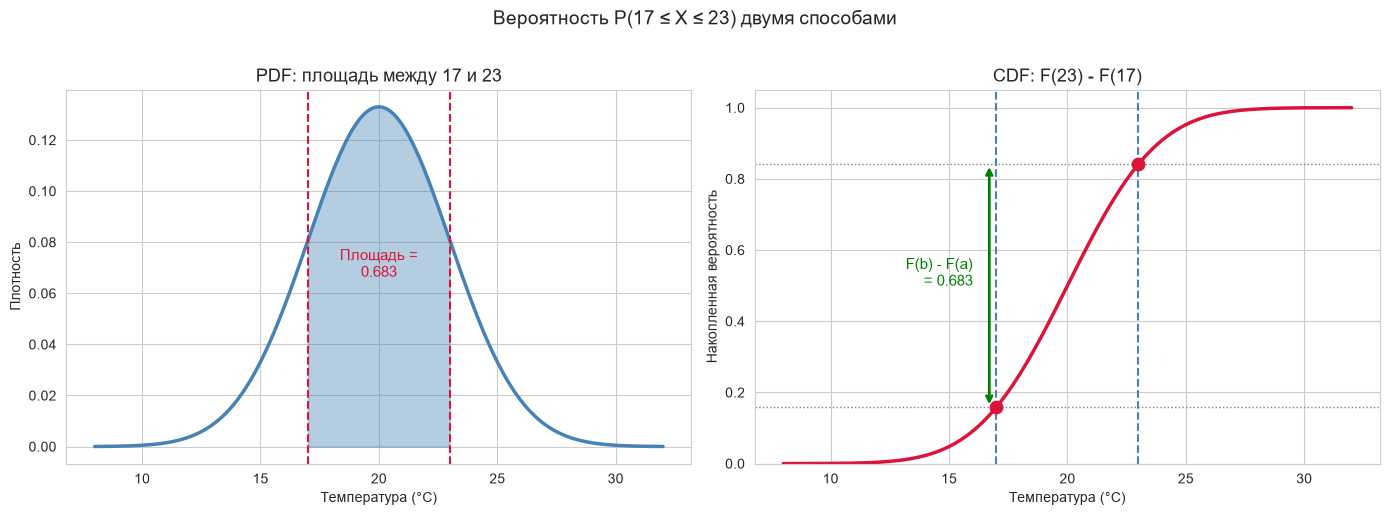

In [4]:
# Интервал
a, b = 17, 23

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF: закрашенная площадь между a и b
mask = (x >= a) & (x <= b)
axes[0].plot(x, pdf, color='steelblue', linewidth=2.5)
axes[0].fill_between(x[mask], pdf[mask], alpha=0.4, color='steelblue')
axes[0].axvline(a, color='crimson', linestyle='--', linewidth=1.5)
axes[0].axvline(b, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_title(f'PDF: площадь между {a} и {b}', fontsize=13)
axes[0].set_xlabel('Температура (°C)')
axes[0].set_ylabel('Плотность')
prob = stats.norm.cdf(b, mu, sigma) - stats.norm.cdf(a, mu, sigma)
axes[0].text((a+b)/2, max(pdf)*0.5,
             f'Площадь =\n{prob:.3f}',
             fontsize=11, color='crimson', ha='center')

# CDF: разность F(b) - F(a)
axes[1].plot(x, cdf, color='crimson', linewidth=2.5)
axes[1].axvline(a, color='steelblue', linestyle='--', linewidth=1.5)
axes[1].axvline(b, color='steelblue', linestyle='--', linewidth=1.5)
axes[1].axhline(stats.norm.cdf(a, mu, sigma), color='gray', linestyle=':', linewidth=1)
axes[1].axhline(stats.norm.cdf(b, mu, sigma), color='gray', linestyle=':', linewidth=1)
axes[1].scatter([a, b],
                [stats.norm.cdf(a, mu, sigma), stats.norm.cdf(b, mu, sigma)],
                color='crimson', s=80, zorder=5)
# Вертикальная стрелка между F(a) и F(b)
axes[1].annotate('', xy=(a-0.3, stats.norm.cdf(b, mu, sigma)),
                 xytext=(a-0.3, stats.norm.cdf(a, mu, sigma)),
                 arrowprops=dict(arrowstyle='<->', color='green', lw=2))
axes[1].text(a-1, (stats.norm.cdf(a, mu, sigma) + stats.norm.cdf(b, mu, sigma))/2,
             f'F(b) - F(a)\n= {prob:.3f}',
             fontsize=11, color='green', ha='right')
axes[1].set_title(f'CDF: F({b}) - F({a})', fontsize=13)
axes[1].set_xlabel('Температура (°C)')
axes[1].set_ylabel('Накопленная вероятность')
axes[1].set_ylim(0, 1.05)

plt.suptitle(f'Вероятность P({a} ≤ X ≤ {b}) двумя способами', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

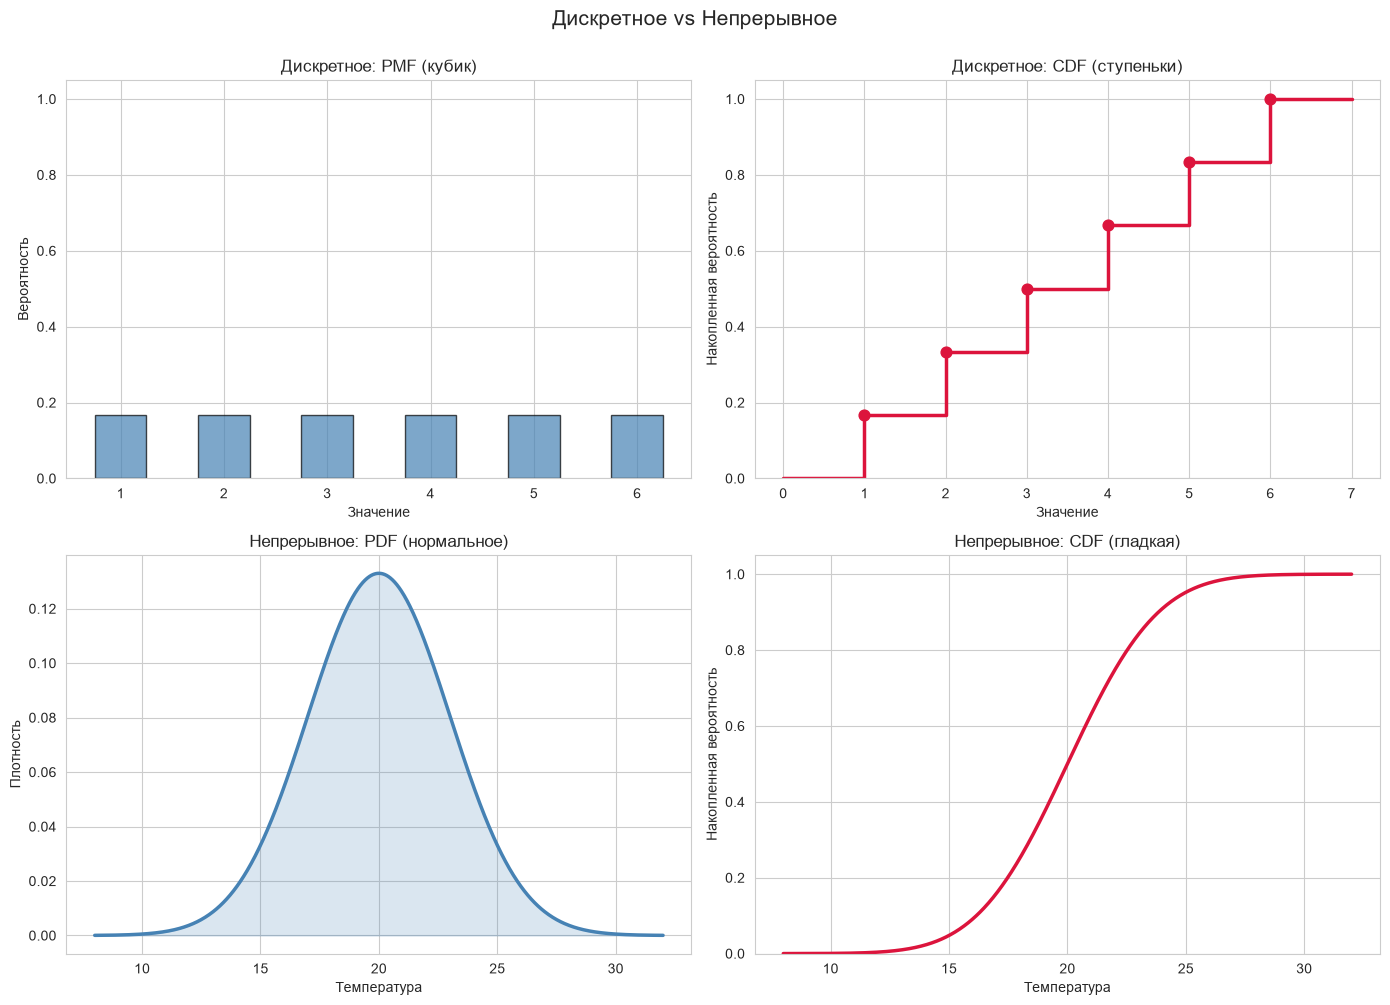

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
values = np.arange(1, 7)
pmf = np.ones(6) / 6
cdf_disc = np.cumsum(pmf)
x_step = np.concatenate([[0], values, [7]])
y_step = np.concatenate([[0], cdf_disc, [1]])

# --- Дискретное: PMF ---
axes[0, 0].bar(values, pmf, width=0.5, color='steelblue',
               alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Дискретное: PMF (кубик)', fontsize=12)
axes[0, 0].set_xlabel('Значение')
axes[0, 0].set_ylabel('Вероятность')
axes[0, 0].set_ylim(0, 1.05)

# --- Дискретное: CDF (ступеньки) ---
axes[0, 1].step(x_step, y_step, where='post', color='crimson', linewidth=2.5)
axes[0, 1].scatter(values, cdf_disc, color='crimson', s=60, zorder=5)
axes[0, 1].set_title('Дискретное: CDF (ступеньки)', fontsize=12)
axes[0, 1].set_xlabel('Значение')
axes[0, 1].set_ylabel('Накопленная вероятность')
axes[0, 1].set_ylim(0, 1.05)

# --- Непрерывное: PDF ---
axes[1, 0].plot(x, pdf, color='steelblue', linewidth=2.5)
axes[1, 0].fill_between(x, pdf, alpha=0.2, color='steelblue')
axes[1, 0].set_title('Непрерывное: PDF (нормальное)', fontsize=12)
axes[1, 0].set_xlabel('Температура')
axes[1, 0].set_ylabel('Плотность')

# --- Непрерывное: CDF (гладкая) ---
axes[1, 1].plot(x, cdf, color='crimson', linewidth=2.5)
axes[1, 1].set_title('Непрерывное: CDF (гладкая)', fontsize=12)
axes[1, 1].set_xlabel('Температура')
axes[1, 1].set_ylabel('Накопленная вероятность')
axes[1, 1].set_ylim(0, 1.05)

plt.suptitle('Дискретное vs Непрерывное', fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

## Матожидание (среднее)

В целом тоже самое, что и в дискретном случаи. Где $x$ - конкретное значение, $f(x)$ - вероятность этого значения (в нашем случаи плотность в точке):

$$
E[X] = \int_{-\infty}^{+\infty} x \cdot f(x) \, dx
$$

## Дисперсия (разброс)

Опять же формула повторяет дискретный случай, только вместо вероятности плотность:

$$
\text{Var}(X) = \int_{-\infty}^{+\infty} (x - \mu)^2 \cdot f(x) \, dx
$$

*Важно! Именно $f(x) \, dx$, а не просто $f(x)$. Суть в том, что умнажая на $dx$ получаем именно нужный нам "бесконечно малый" кусочек в точке*

## Стандартное отклонение

Всё так же без изменений. Корень дисперсии даёт отклонение

$$
\sigma = \sqrt{D[X]} = \sqrt{2.9167} \approx 1.708
$$

## Распределения

«Все модели неверны, но некоторые полезны». Цитата Джорджа Бокса

Во всех формулах распределениях мы будем встречать что-то типо $X \sim ...$ Важно понимать, что дальнейшие буквы в функции полностью описывают распределение (то есть это параметры которые мы сами ставим и их достаточно, что бы начертить распределение)

### Равномерное

Самое простое распределение, где вероятности всех значений равны. a - минимальное значение, b - максимальное значение. К примеру, для распределения для градусов  360 круга получится: a - 0, b - 360:
$$
X \sim U(a,b)
$$

**Формула плотности:**
$$
f(x) = \frac{1}{a-b}, x \in [a, b]
$$

**Матожидание:**
$$
E[X] = \frac{a + b}{2}
$$

**Дисперсия:**
$$
Var(X) = \frac{(b - a)^2}{12}
$$

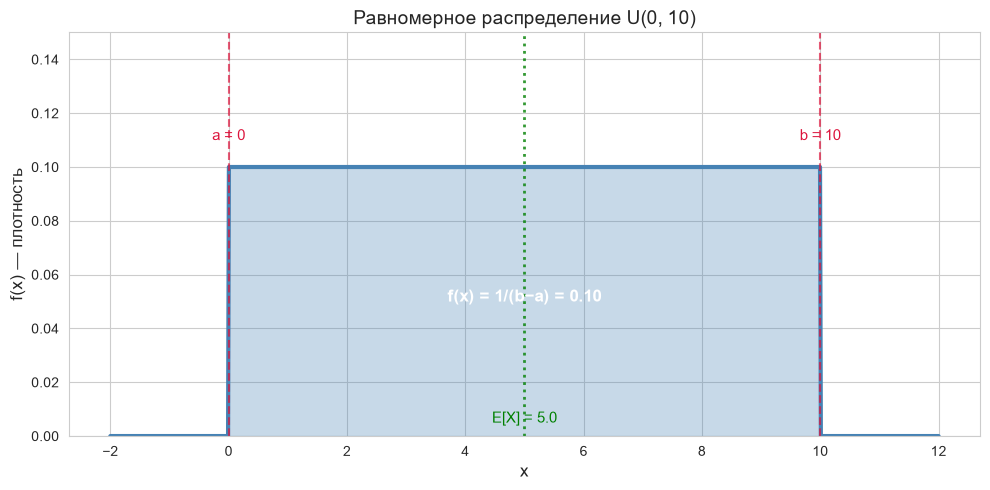

In [6]:
# Параметры
a, b = 0, 10

# Точки для графика
x = np.linspace(-2, 12, 1000)
y = np.where((x >= a) & (x <= b), 1/(b-a), 0)

# График
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, y, color='steelblue', linewidth=3)
ax.fill_between(x, y, alpha=0.3, color='steelblue')

# Вертикальные линии на границах
ax.axvline(a, color='crimson', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(b, color='crimson', linestyle='--', linewidth=1.5, alpha=0.7)

# Подписи
ax.set_title(f'Равномерное распределение U({a}, {b})', fontsize=14)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x) — плотность', fontsize=12)
ax.set_ylim(0, 0.15)

# Аннотации
ax.text(a, 1/(b-a) + 0.01, f'a = {a}', ha='center', fontsize=11, color='crimson')
ax.text(b, 1/(b-a) + 0.01, f'b = {b}', ha='center', fontsize=11, color='crimson')
ax.text((a+b)/2, 1/(b-a)/2, f'f(x) = 1/(b−a) = {1/(b-a):.2f}',
        ha='center', fontsize=12, color='white', fontweight='bold')

# Матожидание
ax.axvline((a+b)/2, color='green', linestyle=':', linewidth=2, alpha=0.8)
ax.text((a+b)/2, 0.005, f'E[X] = {(a+b)/2}', ha='center',
        fontsize=11, color='green')

plt.tight_layout()
plt.show()

### Нормальное распределение (распределение Гаусса)

Нормальное распределение — это колокол. Самое важное распределение в статистике и ML. Читается как "$X$ распределено нормально со средним $\mu$ и дисперсией $\sigma^2$":
$$
X \sim N(\mu,\sigma^2)
$$

*Здесь $\mu$ - центр колокола, $\sigma^2$ - насколько широкий колокол* 

**Формула распределения:**
$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}}*e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

**Матожидание:**

$$
E[X] = \mu
$$

**Дисперсия:**

$$
\text{Var}(X) = \sigma^2
$$

Так же, особенность нормального распределения в том, что есть чёткие ориентиры в стандартных отклонениях:
- $1\sigma$ - описывает 68.3% данных
- $2\sigma$ - описывает 95.4% данных
- $3\sigma$ - описывает 99.7% данных

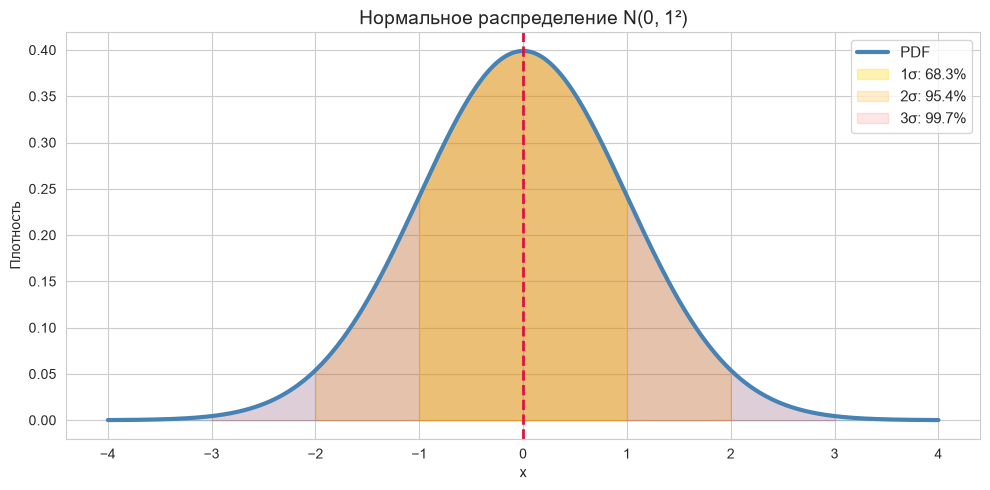

In [7]:
# Параметры
mu, sigma = 0, 1

# Точки
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf = stats.norm.pdf(x, mu, sigma)

# График
fig, ax = plt.subplots(figsize=(10, 5))

# PDF
ax.plot(x, pdf, color='steelblue', linewidth=3, label='PDF')
ax.fill_between(x, pdf, alpha=0.2, color='steelblue')

# Области 1σ, 2σ, 3σ
for k, color, alpha in [(1, 'gold', 0.3), (2, 'orange', 0.2), (3, 'red', 0.1)]:
    mask = (x >= mu - k*sigma) & (x <= mu + k*sigma)
    ax.fill_between(x[mask], pdf[mask], alpha=alpha, color=color,
                    label=f'{k}σ: {stats.norm.cdf(k) - stats.norm.cdf(-k):.1%}')

# Среднее
ax.axvline(mu, color='crimson', linestyle='--', linewidth=2)

ax.set_title(f'Нормальное распределение N({mu}, {sigma}²)', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('Плотность')
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

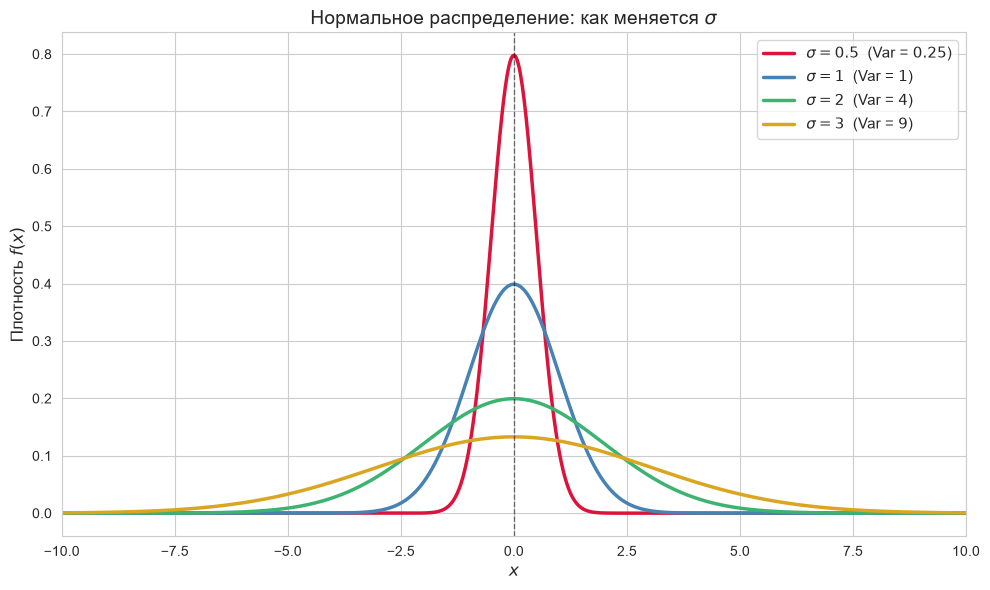

In [13]:
# Фиксируем μ, меняем σ
mu = 0
sigmas = [0.5, 1, 2, 3]
colors = ['crimson', 'steelblue', 'mediumseagreen', 'goldenrod']

fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-10, 10, 1000)

for sigma, color in zip(sigmas, colors):
    pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
    ax.plot(x, pdf, color=color, linewidth=2.5,
            label=f'$\\sigma = {sigma}$  (Var = ${sigma**2}$)')

ax.axvline(mu, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title('Нормальное распределение: как меняется $\\sigma$', fontsize=14)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Плотность $f(x)$', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(-10, 10)

plt.tight_layout()
plt.show()

### Экспоненциальное распределение

Лучший пример этого распределения - это радиактивный распад  
Ключевое: атом не стареет. Он не помнит, сколько уже существует:
- Атом только что образовался $\to$ вероятность распасться в следующую секунду - $\lambda$
- Атом существует уже 1000 лет $\to$ вероятность распасться в следующую секунду - та же $\lambda$
- Атом существует миллион лет $\to$ вероятность та же $\lambda$

Атом не «устаёт». Он не «близок к распаду». Он не помнит прошлого. Каждый момент — как первый

Исходя из этого, по графику мы видим, что вероятность условного атома распаться в первые промежутки его жизни наиболее высокая, в то время как вероятность, что он проживёт долго очень маленькая

*По оси $x$ чаще всего время, но не всегда*

В формуле $\lambda$ обозначает интенсивность: сколько событий происходит в среднем за единицу времени (например, 3 звонка в час):
$$
X \sim Exp(\lambda)
$$

**Формула распределения:**
$$
f(x) = \lambda e^{-\lambda x}, x \ge 0
$$

**Матожидание:**

$$
E[X] = \frac{1}{\lambda}
$$

*На примере с атомом, можно сказать, что именно за этот промежуток большинство атомов распадается*

**Дисперсия:**

$$
\text{Var}(X) = \frac{1}{\lambda^2}
$$

*Особенность этого распределения, что стандартное отклонение = $\frac{1}{\lambda}$, что полность совпадает с матожиданием*

**Сколько ждать, чтобы осталось 50% от начального количества или время, через которое накопится 50% событий**
$$
T_{1/2} = \frac{ln 2}{\lambda}
$$

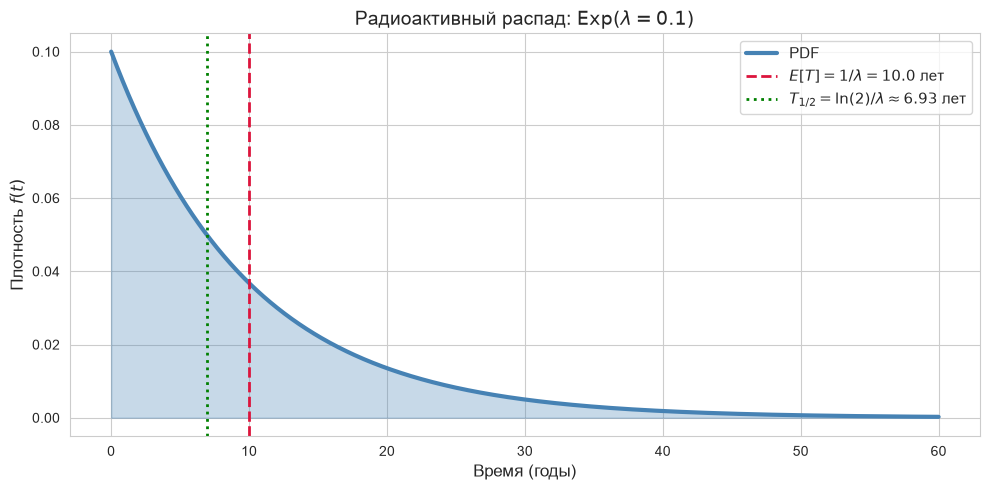

In [9]:
lam = 0.1
t = np.linspace(0, 60, 1000)
pdf = stats.expon.pdf(t, scale=1/lam)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t, pdf, color='steelblue', linewidth=3, label='PDF')
ax.fill_between(t, pdf, alpha=0.3, color='steelblue')

mean = 1/lam
ax.axvline(mean, color='crimson', linestyle='--', linewidth=2,
           label=f'$E[T] = 1/\\lambda = {mean:.1f}$ лет')

half_life = np.log(2) / lam
ax.axvline(half_life, color='green', linestyle=':', linewidth=2,
           label=f'$T_{{1/2}} = \\ln(2)/\\lambda \\approx {half_life:.2f}$ лет')

ax.set_title(f'Радиоактивный распад: $\\mathrm{{Exp}}(\\lambda = {lam})$', fontsize=14)
ax.set_xlabel('Время (годы)', fontsize=12)
ax.set_ylabel('Плотность $f(t)$', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

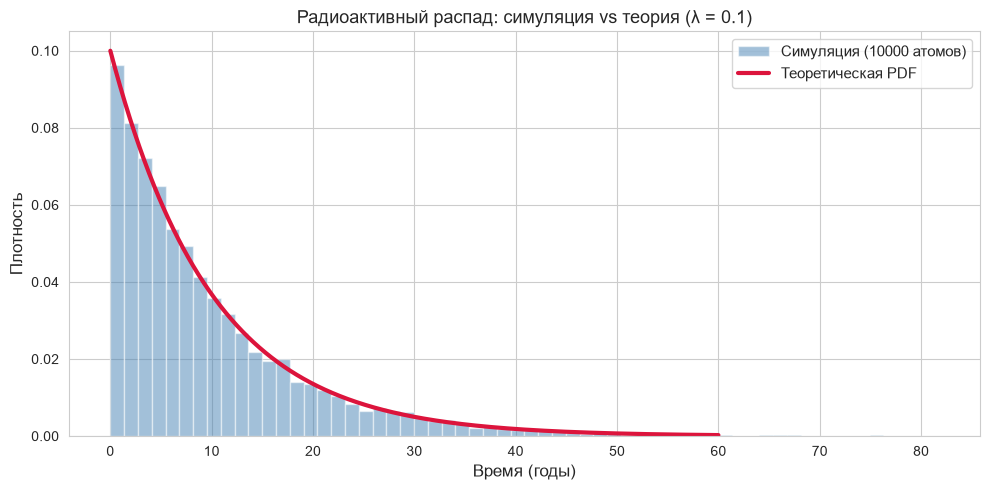

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

# Генерируем времена распада 10000 атомов
np.random.seed(42)
n_atoms = 10000
decay_times = np.random.exponential(scale=1/lam, size=n_atoms)

# Гистограмма (нормированная)
ax.hist(decay_times, bins=60, density=True, alpha=0.5,
        color='steelblue', edgecolor='white', label='Симуляция (10000 атомов)')

# Теоретическая PDF
t = np.linspace(0, 60, 1000)
pdf = stats.expon.pdf(t, scale=1/lam)
ax.plot(t, pdf, color='crimson', linewidth=3, label='Теоретическая PDF')

ax.set_title(f'Радиоактивный распад: симуляция vs теория (λ = {lam})', fontsize=13)
ax.set_xlabel('Время (годы)', fontsize=12)
ax.set_ylabel('Плотность', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

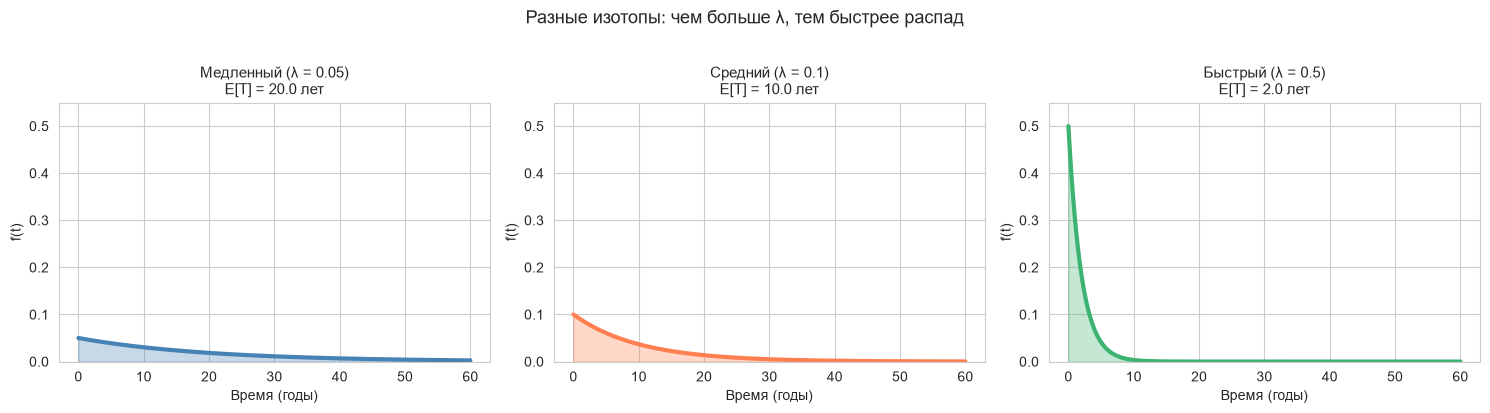

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lambdas = [0.05, 0.1, 0.5]
colors = ['steelblue', 'coral', 'mediumseagreen']
labels = ['Медленный (λ = 0.05)', 'Средний (λ = 0.1)', 'Быстрый (λ = 0.5)']

for ax, lam, color, label in zip(axes, lambdas, colors, labels):
    t = np.linspace(0, 60, 1000)
    pdf = stats.expon.pdf(t, scale=1/lam)
    
    ax.plot(t, pdf, color=color, linewidth=3)
    ax.fill_between(t, pdf, alpha=0.3, color=color)
    ax.set_title(f'{label}\nE[T] = {1/lam:.1f} лет',
                 fontsize=11)
    ax.set_xlabel('Время (годы)')
    ax.set_ylabel('f(t)')
    ax.set_ylim(0, 0.55)

plt.suptitle('Разные изотопы: чем больше λ, тем быстрее распад',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Бета-распределение
$$
X \sim Beta(\alpha, \beta)
$$

- $\alpha$ - это число "удач"
- $\beta$ - это число "неудач"

Причём, тут есть особенность, на самом деле формула выглядит так:
$$
Beta(\alpha_0 + \alpha, \beta_0 + \beta)
$$
Где:
- $\alpha$ и $\beta$ - это наши конкретные данные. Например, результаты подбрасывания монетки
- $\alpha_0$ и $\beta_0$ - это начальные данные уверенности. По умолчанию обычно это (1,1) - что означает "Ничего не знаю" о данных

Вот другие варианты для $\alpha_0$ и $\beta_0$:
- (5, 1) - Скорее ближе к 1
- (1, 5) - Скорее ближе к 0
- (10, 10) - Уверен, что около 0.5
- (100, 100) - Очень уверен, что около 0.5 (То есть чем выше число, тем больше уверенность)

*Среди начальных значений есть такие как: Джеффриса, Холдейна и т.д. Смотреть по необходимости*

### Гамма-распределение

Гамма-распределение - это обобщение экспоненциального. Если экспоненциальное - это время до первого события, то гамма - время до $k$-го события

Пример: звонки в колл-центр. В среднем 3 звонка в час
- Экспоненциальное: сколько ждать первого звонка?
- Гамма: сколько ждать пятого звонка?

Гамма = сумма нескольких экспоненциальных:
$$
X_1 + X_2 + ... + X_k \sim Г(k, \lambda)
$$
где, $\lambda$ - интенсивность, как было выше

Или основная формула:
$$
X \sim Г(\alpha, \beta)
$$
где:
- $\alpha > 0$ - форма (сколько событий ждём)
- $\beta > 0$ - скорость (интенсивность)

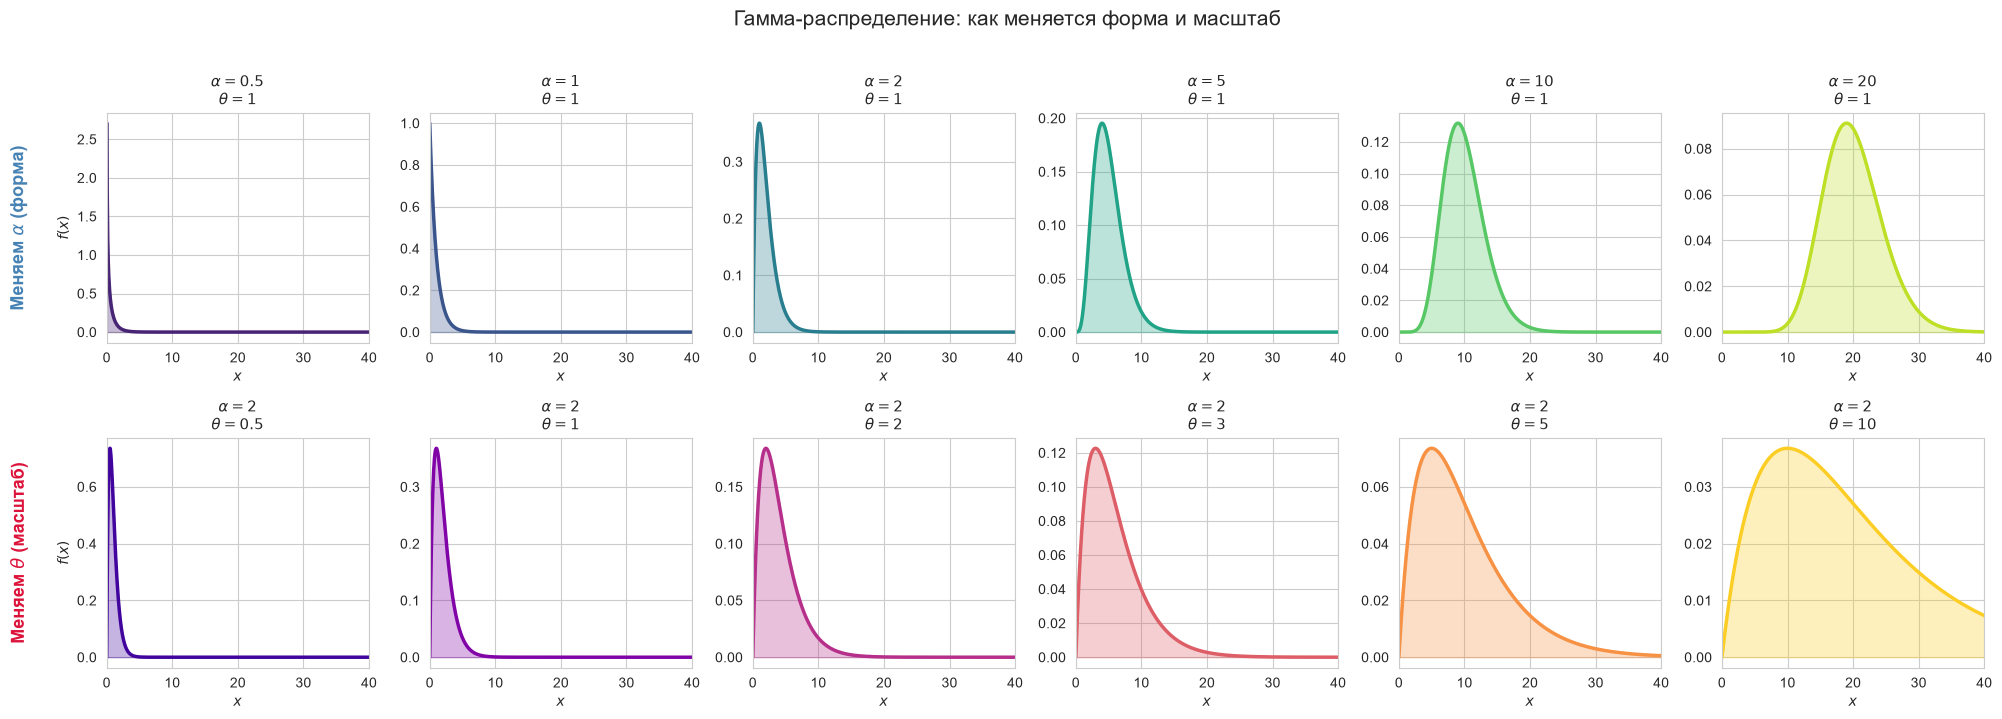

In [5]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

# ===== Верхний ряд: меняем α (форма), фиксируем θ = 1 =====
theta = 1
alphas = [0.5, 1, 2, 5, 10, 20]
colors_top = plt.cm.viridis(np.linspace(0.1, 0.9, len(alphas)))

x = np.linspace(0, 40, 1000)

for i, (alpha, color) in enumerate(zip(alphas, colors_top)):
    ax = axes[0, i]
    pdf = stats.gamma.pdf(x, a=alpha, scale=theta)
    ax.plot(x, pdf, color=color, linewidth=2.5)
    ax.fill_between(x, pdf, alpha=0.3, color=color)
    ax.set_title(f'$\\alpha = {alpha}$\n$\\theta = {theta}$', fontsize=11)
    ax.set_xlabel('$x$')
    if i == 0:
        ax.set_ylabel('$f(x)$')
    ax.set_xlim(0, 40)

# ===== Нижний ряд: меняем θ (масштаб), фиксируем α = 2 =====
alpha = 2
thetas = [0.5, 1, 2, 3, 5, 10]
colors_bottom = plt.cm.plasma(np.linspace(0.1, 0.9, len(thetas)))

for i, (theta, color) in enumerate(zip(thetas, colors_bottom)):
    ax = axes[1, i]
    pdf = stats.gamma.pdf(x, a=alpha, scale=theta)
    ax.plot(x, pdf, color=color, linewidth=2.5)
    ax.fill_between(x, pdf, alpha=0.3, color=color)
    ax.set_title(f'$\\alpha = {alpha}$\n$\\theta = {theta}$', fontsize=11)
    ax.set_xlabel('$x$')
    if i == 0:
        ax.set_ylabel('$f(x)$')
    ax.set_xlim(0, 40)

# Подписи рядов
axes[0, 0].annotate('Меняем $\\alpha$ (форма)',
                    xy=(-0.3, 0.5), xycoords='axes fraction',
                    fontsize=13, rotation=90, va='center', ha='right',
                    color='steelblue', fontweight='bold')
axes[1, 0].annotate('Меняем $\\theta$ (масштаб)',
                    xy=(-0.3, 0.5), xycoords='axes fraction',
                    fontsize=13, rotation=90, va='center', ha='right',
                    color='crimson', fontweight='bold')

plt.suptitle('Гамма-распределение: как меняется форма и масштаб',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

*Второй параметр может быть разным. То есть это либо $\beta$ которая по сути $\lambda$, либо $\theta = \frac{1}{\beta}$ и обозначает уже масштаб*

**Формула распределения:**
$$
f(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} \, x^{\alpha - 1} e^{-\beta x}, \quad x > 0
$$

*Подробнее о $\Gamma(\alpha)$ в разделе "Специальные функции"*

**Матожидание:**

$$
E[X] = \frac{\alpha}{\beta}
$$

**Дисперсия:**

$$
\text{Var}(X) = \frac{\alpha}{\beta^2}
$$

### Логнормальное распределение

Основная фишка этого распределения в том, что если взять от него логарифм, то получим нормальное распределение
$$
\ln(X) \sim N(\mu, \sigma^2) \quad \Rightarrow \quad X \sim \text{LogNormal}(\mu, \sigma^2)
$$

**Формула распределения:**
$$
f(x) = \frac{1}{x\sigma\sqrt{2\pi}} \, e^{-\frac{(\ln x - \mu)^2}{2\sigma^2}}, \quad x > 0
$$

**Матожидание**

$$
E[X] = e^{\mu + \sigma^2/2}
$$

**Медиана**

$$
\text{Median}(X) = e^\mu
$$

**Дисперсия**

$$
\text{Var}(X) = \left(e^{\sigma^2} - 1\right) e^{2\mu + \sigma^2}
$$

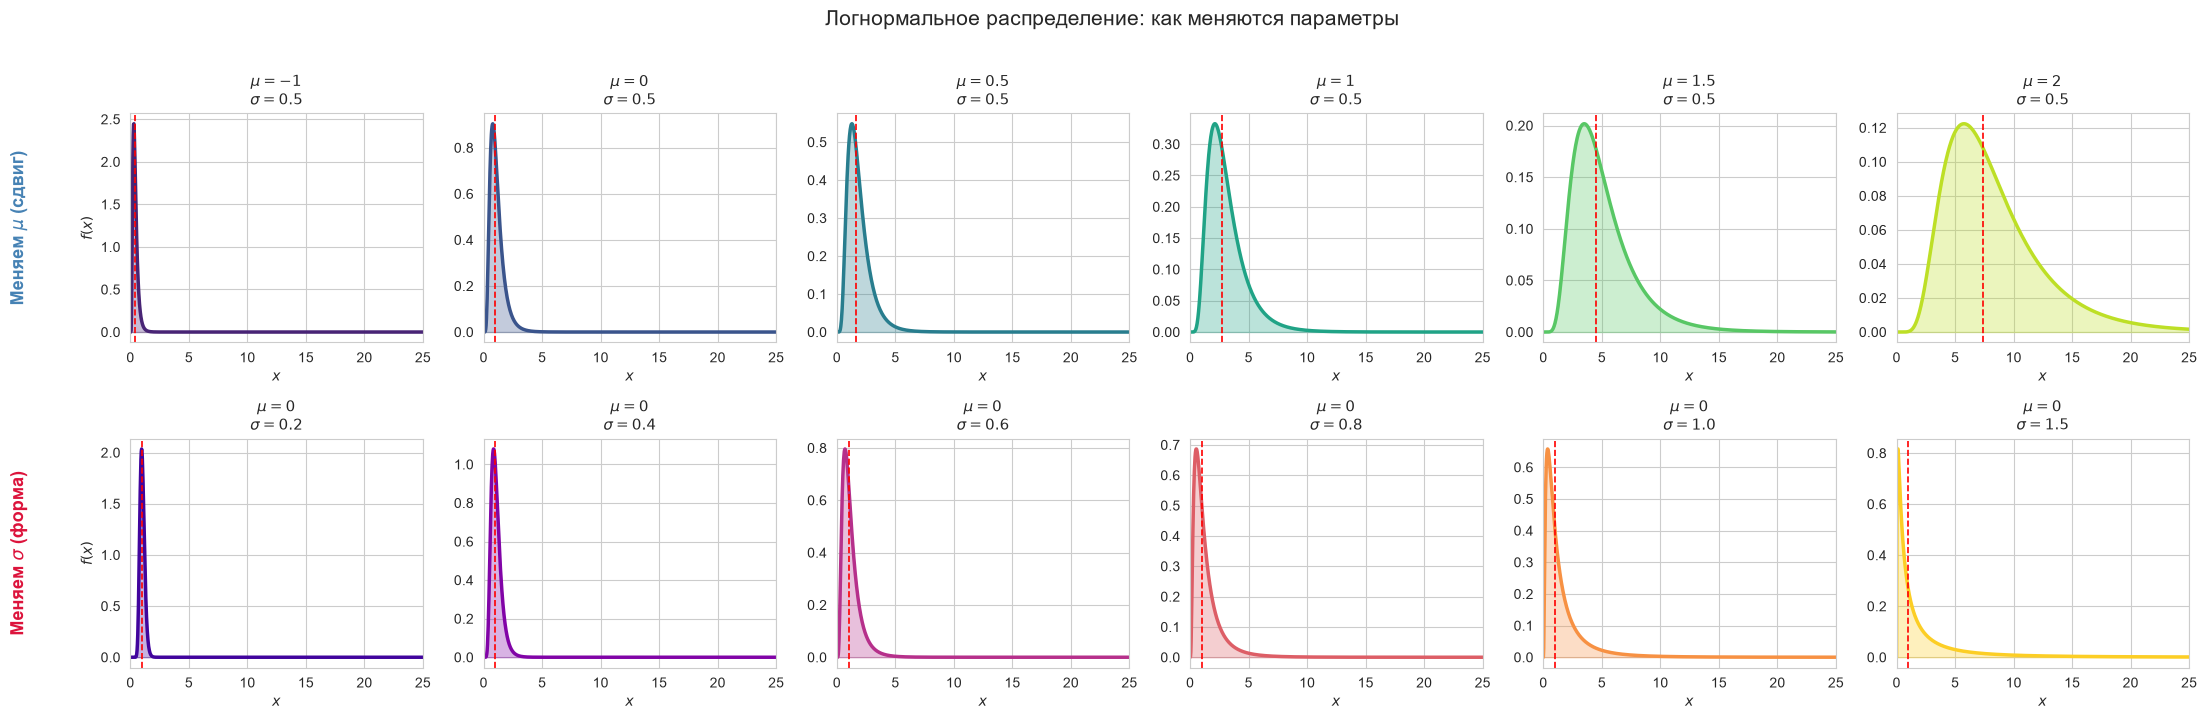

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

# ============================================
# ВЕРХНИЙ РЯД: меняем μ (log-среднее), фиксируем σ = 0.5
# ============================================
sigma = 0.5
mus = [-1, 0, 0.5, 1, 1.5, 2]
colors_top = plt.cm.viridis(np.linspace(0.1, 0.9, len(mus)))

x = np.linspace(0, 30, 1000)

for i, (mu, color) in enumerate(zip(mus, colors_top)):
    ax = axes[0, i]
    pdf = stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    ax.plot(x, pdf, color=color, linewidth=2.5)
    ax.fill_between(x, pdf, alpha=0.3, color=color)
    
    # Медиана
    median = np.exp(mu)
    ax.axvline(median, color='red', linestyle='--', linewidth=1.2)
    
    ax.set_title(f'$\\mu = {mu}$\n$\\sigma = {sigma}$', fontsize=11)
    ax.set_xlabel('$x$')
    if i == 0:
        ax.set_ylabel('$f(x)$')
    ax.set_xlim(0, 25)

# ============================================
# НИЖНИЙ РЯД: меняем σ (log-стандартное отклонение), фиксируем μ = 0
# ============================================
mu = 0
sigmas = [0.2, 0.4, 0.6, 0.8, 1.0, 1.5]
colors_bottom = plt.cm.plasma(np.linspace(0.1, 0.9, len(sigmas)))

for i, (sigma, color) in enumerate(zip(sigmas, colors_bottom)):
    ax = axes[1, i]
    pdf = stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    ax.plot(x, pdf, color=color, linewidth=2.5)
    ax.fill_between(x, pdf, alpha=0.3, color=color)
    
    # Медиана
    median = np.exp(mu)
    ax.axvline(median, color='red', linestyle='--', linewidth=1.2)
    
    ax.set_title(f'$\\mu = {mu}$\n$\\sigma = {sigma}$', fontsize=11)
    ax.set_xlabel('$x$')
    if i == 0:
        ax.set_ylabel('$f(x)$')
    ax.set_xlim(0, 25)

# Подписи рядов
axes[0, 0].annotate('Меняем $\\mu$ (сдвиг)',
                    xy=(-0.35, 0.5), xycoords='axes fraction',
                    fontsize=13, rotation=90, va='center', ha='right',
                    color='steelblue', fontweight='bold')
axes[1, 0].annotate('Меняем $\\sigma$ (форма)',
                    xy=(-0.35, 0.5), xycoords='axes fraction',
                    fontsize=13, rotation=90, va='center', ha='right',
                    color='crimson', fontweight='bold')

plt.suptitle('Логнормальное распределение: как меняются параметры',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Ключевое отличие

| Распределение | Пик в нуле? |
|---|---|
| Экспоненциальное | Всегда |
| Гамма ($\alpha \le 1$) | Да |
| Гамма ($\alpha > 1$) | Нет, сдвинут |
| Логнормальное | Никогда не в нуле |

## Совместные непрерывные распределения

**Вероятность области:**

$$
P((X, Y) \in A) = \iint_A f(x, y) \, dx \, dy
$$
где $A$ в отличии от случая с одной переменной не одно конкретное число $x$, а поверхность, например, для роста$(X)$ и веса$(Y)$:
$$
P(170 \le X \le 180, 60 \le Y \le 80)
$$

**Маргинальные (когда хотим убрать X или Y):**

$$
f_X(x) = \int f(x, y) \, dy
$$

$$
f_Y(y) = \int f(x, y) \, dx
$$

**Независимость:**

$$
f(x, y) = f_X(x) \cdot f_Y(y)
$$

**Условное:**

$$
f_{Y \mid X}(y \mid x) = \frac{f(x, y)}{f_X(x)}
$$

**Ковариация:**

$$
\mathrm{Cov}(X, Y) = E[XY] - E[X] E[Y]
$$

**Корреляция:**

$$
\rho = \frac{\mathrm{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$

**Двумерное нормальное (распределение):** $ (X, Y) \sim N(\mu_X, \mu_Y, \sigma_X^2, \sigma_Y^2, \rho) $.

**Важно:** для двумерного нормального $ \rho = 0 \Leftrightarrow $ независимость. То есть ИСКЛЮЧИТЕЛЬНО для двумерного нормального работает случай, что корреляция = 0 гарантирует независимые $X$ и $Y$

## Теорема Байеса (непрерывный случай)

**Формула:**

$$
f(\theta \mid x) = \frac{f(x \mid \theta) \cdot f(\theta)}{f(x)}
$$

**Знаменатель:**

$$
f(x) = \int f(x \mid \theta) \cdot f(\theta) \, d\theta
$$

**Компоненты:**
- $ f(\theta) $ — априорная плотность
- $ f(x \mid \theta) $ — правдоподобие
- $ f(\theta \mid x) $ — апостериорная плотность
- $ f(x) $ — нормировка

**Связь с дискретным:** сумма → интеграл, вероятность → плотность.